In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)
rng = np.random.default_rng(42)

Part A — demonstrate overfitting (the deliverable's core)  
TASK 01  
Polynomial regression at degrees 1, 5, 15

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Generate noisy data from a known curve
n_points = 30
x = np.sort(rng.uniform(0, 1, n_points))
y_true = np.sin(2 * np.pi * x)

y = y_true + rng.normal(0, 0.25, n_points)

# a fine grid to draw the true underlying curve
x_grid = np.linspace(0, 1, 200)
y_grid_true = np.sin(2 * np.pi * x_grid)

print(f"{n_points} noisy data points generated from a sine wave")

30 noisy data points generated from a sine wave


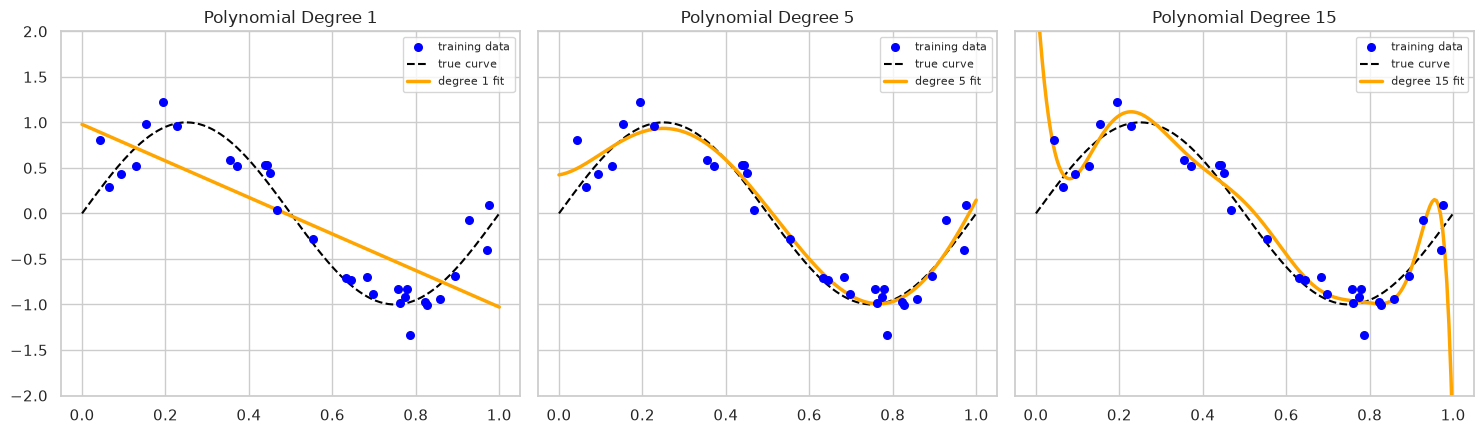

In [4]:
# Fit polynomial regression for degrees 1, 5, 15
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, d in zip(ax, [1, 5, 15]):
    poly = PolynomialFeatures(degree=d)
    Xp = poly.fit_transform(x.reshape(-1, 1))
    X_grid_poly = poly.transform(x_grid.reshape(-1, 1))

    # Fit model
    model = LinearRegression().fit(Xp, y)
    y_fit = model.predict(X_grid_poly)

    ax.scatter(x, y, color="blue", s=30, zorder=3, label='training data')
    ax.plot(x_grid, y_grid_true, color='black', lw=1.5, ls='--', label='true curve')
    ax.plot(x_grid, y_fit, color='orange', lw=2.5, label=f"degree {d} fit")
    ax.set_ylim(-2, 2)
    ax.set_title(f'Polynomial Degree {d}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
# Calculate both errors
print("Error Comparison")
print("-" * 50)

for d in [1, 5, 15]:
    poly = PolynomialFeatures(degree=d)
    Xp = poly.fit_transform(x.reshape(-1, 1))
    X_grid_poly = poly.transform(x_grid.reshape(-1, 1))

    model = LinearRegression().fit(Xp, y)
    y_fit = model.predict(X_grid_poly)

    train_error = mean_squared_error(y, model.predict(Xp))
    true_error = mean_squared_error(y_grid_true, y_fit)

    
    print(f"\nDegree {d:2}:")
    print(f"   Training Error   = {train_error:.4f}")
    print(f"   True Curve Error = {true_error:.4f}")

Error Comparison
--------------------------------------------------

Degree  1:
   Training Error   = 0.1978
   True Curve Error = 0.2016

Degree  5:
   Training Error   = 0.0349
   True Curve Error = 0.0088

Degree 15:
   Training Error   = 0.0238
   True Curve Error = 0.1848


1. Degree 1 —>
Underfitting: A straight line cannot capture the curved shape of the sine wave. Therefore, both its training error and true-curve error remain relatively high.
3. Degree 5 —>
Close to right: It has enough flexibility to capture the main shape of the sine wave while avoiding excessive sensitivity to the random noise. Its true-curve error should therefore be among the lowest.
5. Degree 15 —>
Overfitting: The highly flexible polynomial can drive the training error very low by following the noisy observations. However, if its true-curve error is higher than degree 5, that gap demonstrates that it is fitting noise rather than the underlying relationship.

TASK 02  
The bias-variance curve

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    x.reshape(-1, 1), y, test_size=0.3, random_state=1
)

degrees = range(1, 16)
train_errors, test_errors = [], []

for degree in degrees:
    # Create polynomial Feature
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # Fit model in Training data
    model = LinearRegression().fit(X_train_poly, y_train)
    
    # MSE with prediction
    train_mse = mean_squared_error(y_train, model.predict(X_train_poly))
    test_mse = mean_squared_error(y_test, model.predict(X_test_poly))

    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Identify the degree with the lowest TEST error
best_degree = degrees[np.argmin(test_errors)]

print("Best Degrees :", best_degree)
print("Lowest test MSE :", min(test_errors))

print("\n Degrees   |   Train MSE   |   Test MSE")
for d, tr, te in zip(degrees, train_errors, test_errors):
    print(f"  {d:4}     |     {tr:.4f}    |    {te:.4f}")

Best Degrees : 12
Lowest test MSE : 0.01536131500101729

 Degrees   |   Train MSE   |   Test MSE
     1     |     0.2180    |    0.1937
     2     |     0.2108    |    0.1811
     3     |     0.0457    |    0.0254
     4     |     0.0445    |    0.0223
     5     |     0.0434    |    0.0182
     6     |     0.0433    |    0.0172
     7     |     0.0290    |    0.0347
     8     |     0.0280    |    0.0324
     9     |     0.0290    |    0.0339
    10     |     0.0299    |    0.0352
    11     |     0.0228    |    0.0156
    12     |     0.0243    |    0.0154
    13     |     0.0259    |    0.0161
    14     |     0.0274    |    0.0176
    15     |     0.0287    |    0.0195


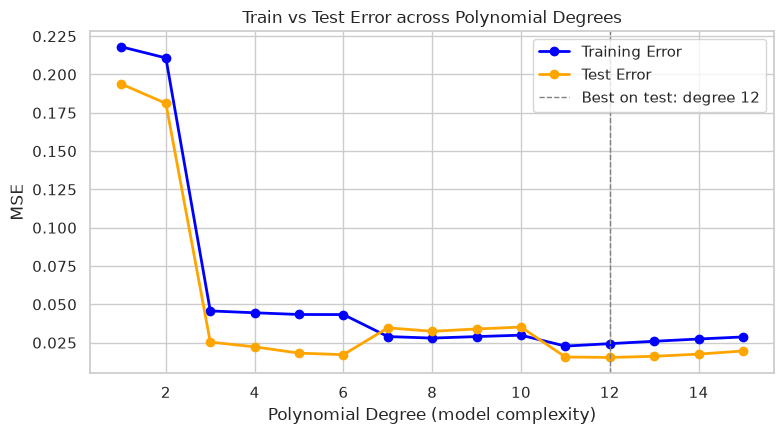

In [7]:
# Plot error curves
fig, ax = plt.subplots()

ax.plot(degrees, train_errors, "o-", color='blue', lw=2, label='Training Error')
ax.plot(degrees, test_errors, "o-", color='orange', lw=2, label='Test Error')
ax.axvline(best_degree, color='gray', ls='--', lw=1, label=f"Best on test: degree {best_degree}")
ax.set_title("Train vs Test Error across Polynomial Degrees")
ax.set_xlabel("Polynomial Degree (model complexity)")
ax.set_ylabel("MSE")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

* At low polynomial degrees, both training and test errors are usually relatively high because the model is too simple to capture the underlying pattern, indicating high bias and low variance.
* As the degree increases, training error generally keeps decreasing, while test error first decreases and then increases; the rising test error at high degrees indicates overfitting and high variance, with the degree having the minimum test error representing the bias-variance sweet spot.

Part B — Ridge, Lasso, and Elastic Net on real data  
TASK 03  
Apply all three regularizers

In [8]:
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("california_housing.csv")
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal'].values
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Feature Names : {feature_names}")
print(f"Training on {len(X_train)}, Testing on {len(X_test)} districts")

Feature Names : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Training on 4000, Testing on 1000 districts


In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score

results = []

# Linear Regression
model = LinearRegression().fit(X_train_scaled, y_train)
results.append({
    "Model" : "Linear Regression",
    "Strength (alpha)" : "-",
    "Test R2" : r2_score(y_test, model.predict(X_test_scaled)),
    "Exact Zero Coeff" : (model.coef_ == 0).sum()
})


# Ridge Regression
for alpha in [0.01, 1, 10, 100]:
    ridge = Ridge(alpha=alpha).fit(X_train_scaled, y_train)
    results.append({
        "Model" : "Ridge",
        "Strength (alpha)" : alpha,
        "Test R2" : r2_score(y_test, ridge.predict(X_test_scaled)),
        "Exact Zero Coeff" : (ridge.coef_==0).sum()
    })


# Lasso Regression
for alpha in [0.001, 0.01, 0.05, 0.1, 0.3]:
    lasso = Lasso(alpha=alpha, max_iter=10000).fit(X_train_scaled, y_train)
    results.append({
        "Model" : "Lasso",
        "Strength (alpha)" : alpha,
        "Test R2" : r2_score(y_test, lasso.predict(X_test_scaled)),
        "Exact Zero Coeff" : (lasso.coef_==0).sum()
    })


# Elastic Net
for alpha in [0.1, 0.5, 0.9]:
    en = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000).fit(X_train_scaled, y_train)
    results.append({
        "Model" : "ElasticNet",
        "Strength (alpha)" : alpha,
        "Test R2" : r2_score(y_test, en.predict(X_test_scaled)),
        "Exact Zero Coeff" : (en.coef_==0).sum()
    })


# Create Comparison Table
results_df = pd.DataFrame(results)
results_df

,Model,Strength (alpha),Test R2,Exact Zero Coeff
0,Linear Regression,-,0.838290,0
1,Ridge,0.01,0.838290,0
2,Ridge,1,0.838311,0
3,Ridge,10,0.838501,0
4,Ridge,100,0.839830,0
5,Lasso,0.001,0.838391,0
6,Lasso,0.01,0.838258,2
7,Lasso,0.05,0.826750,3
8,Lasso,0.1,0.790197,3
9,Lasso,0.3,0.664119,7


Ridge regression has all coefficients 0 but Lasso has 1 0.

* Linear Regression: Fits the coefficients by minimizing squared error without any regularization, so coefficients are free to take whatever values best fit the training data.
* Ridge: Adds an L2 penalty that shrinks large coefficients toward zero, reducing overfitting while generally keeping all features.
* Lasso: Adds an L1 penalty that can shrink some coefficients exactly to zero, effectively performing feature selection.
* Elastic Net: Combines L1 and L2 penalties, so it can both shrink coefficients and set some of them exactly to zero.

TASK 04  
Prove Lasso does feature selection

In [10]:
from sklearn.linear_model import Lasso

results = []

for alpha in np.logspace(-3, 0, 20):
    lasso = Lasso(alpha=alpha, max_iter=5000).fit(X_train_scaled, y_train)

    dropped = [
        f for f, c in zip(feature_names, lasso.coef_)
        if c == 0
    ]

    remaining = [
        f for f, c in zip(feature_names, lasso.coef_)
        if c != 0
    ]

    results.append({
        "alpha": alpha,
        "dropped": dropped,
        "remaining": remaining
    })

    print(f"Alpha = {alpha:.4f}")
    print("Zeroed Out Features:", dropped if dropped else "None")
    print("Remainig Features:", remaining)

Alpha = 0.0010
Zeroed Out Features: None
Remainig Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Alpha = 0.0014
Zeroed Out Features: None
Remainig Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Alpha = 0.0021
Zeroed Out Features: ['AveBedrms']
Remainig Features: ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Alpha = 0.0030
Zeroed Out Features: ['AveBedrms', 'Population']
Remainig Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude']
Alpha = 0.0043
Zeroed Out Features: ['AveBedrms', 'Population']
Remainig Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude']
Alpha = 0.0062
Zeroed Out Features: ['AveBedrms', 'Population']
Remainig Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude']
Alpha = 0.0089
Zeroed Out Features: ['AveBedrms', 'Population'

In [11]:
# The FIRST feature to become zero
for result in results:
    if result["dropped"]:
        print("First feature dropped")
        print("-" * 22)
        print(f"Alpha: {result["alpha"]:.4f}")
        print("Feature:", result["dropped"][0])
        break

First feature dropped
----------------------
Alpha: 0.0021
Feature: AveBedrms


In [12]:
# when only ONE feature remains
for result in results:
    if len(result["remaining"]) == 1:
        print("Only one feature Remains")
        print("-" * 25)
        print(f"Alpha: {result["alpha"]:.4f}")
        print("Feature:", result["remaining"][0])
        break

Only one feature Remains
-------------------------
Alpha: 0.2336
Feature: MedInc


The feature that survives longest is generally the one whose relationship with the target is strongest after accounting for the other features.

Because your features are standardized, Lasso is comparing coefficients on the same scale. A feature with a relatively strong and useful predictive contribution tends to retain a non-zero coefficient even as alpha increases, while weaker or redundant features are pushed to exactly zero first.

One important point: np.logspace(-3, 0, 20) means you're testing 20 alpha values logarithmically spaced between 0.001 and 1.0. So the values are not evenly spaced like 0.1, 0.2, 0.3...; they become progressively larger.

Part C — the geometry, the paths, and honest tuning  
TASK 05  
Explain the L1 vs L2 geometry in your own words

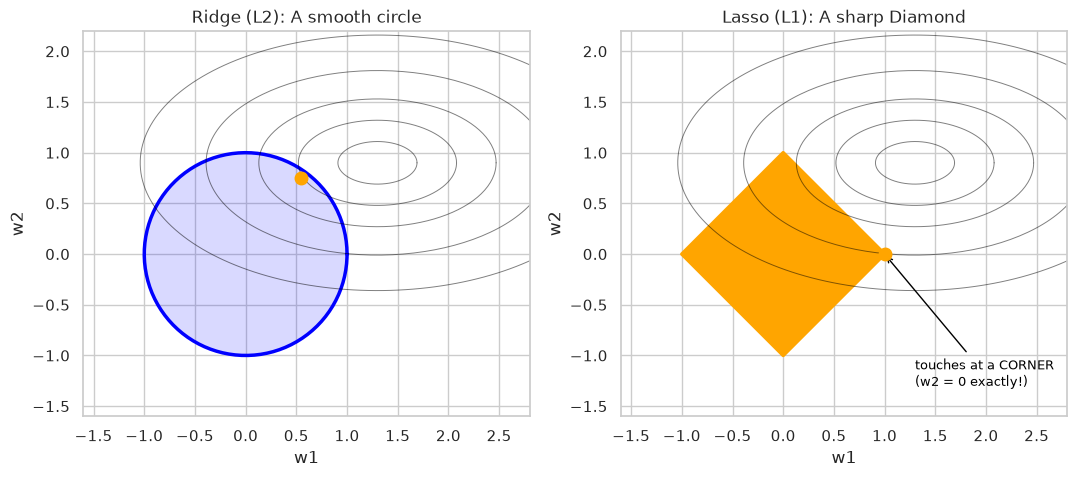

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))

theta = np.linspace(0, 2*np.pi, 200)


# For Ridge (L2)
ax = axes[0]
circle_x, circle_y = np.cos(theta), np.sin(theta)
ax.plot(circle_x, circle_y, color='blue', lw=2.5)
ax.fill(circle_x, circle_y, color='blue', alpha=0.15)

for r in [0.3, 0.6, 0.9, 1.3, 1.8]:
    ell_x = 1.3 + r*np.cos(theta)*1.3
    ell_y = 0.9 + r*np.sin(theta)*0.7
    ax.plot(ell_x, ell_y, color='black', lw=0.7, alpha=0.5)
    
ax.plot(0.55, 0.75, 'o', color='orange', markersize=9, zorder=5)
ax.set_title("Ridge (L2): A smooth circle")
ax.set_xlim(-1.6, 2.8)
ax.set_ylim(-1.6, 2.2)
ax.set_aspect("equal")
ax.set_xlabel("w1")
ax.set_ylabel("w2")


# For Lasso (L1)
ax = axes[1]
diamond_x = np.array([1, 0, -1, 0, 1])
diamond_y = np.array([0, 1, 0, -1, 0])

ax.plot(diamond_x, diamond_y, color="orange", lw=2.5)
ax.fill(diamond_x, diamond_y, color='orange', lw=0.15)

for r in [0.3, 0.6, 0.9, 1.3, 1.8]:
    ell_x = 1.3 + r*np.cos(theta)*1.3
    ell_y = 0.9 + r*np.sin(theta)*0.7
    ax.plot(ell_x, ell_y, color='black', lw=0.7, alpha=0.5)

ax.plot(1.0, 0.0, 'o', color='orange', markersize=9, zorder=5)
ax.annotate("touches at a CORNER\n(w2 = 0 exactly!)", xy=(1.0, 0.0), xytext=(1.3, -1.3),
           fontsize=9, color='black', arrowprops=dict(arrowstyle="->", color="black"))

ax.set_title("Lasso (L1): A sharp Diamond")
ax.set_xlim(-1.6, 2.8)
ax.set_ylim(-1.6, 2.2)
ax.set_aspect("equal")
ax.set_xlabel("w1")
ax.set_ylabel("w2")


plt.tight_layout()
plt.show()

The L1 constraint has sharp corners where one or more coefficients can lie exactly on an axis. When the model's loss function is minimized together with the L1 penalty, the optimum often lands on one of these corners. At a corner, one coefficient becomes exactly zero, which is why Lasso can perform feature selection. In contrast, the L2 constraint is a smooth circle with no sharp corners. The optimum can move smoothly around its boundary, so coefficients are usually pushed toward zero but are rarely made exactly zero. This is why Ridge generally keeps all features while Lasso can remove some features completely.

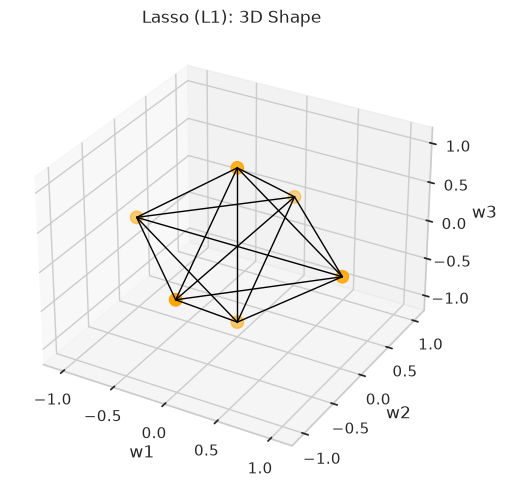

In [19]:
# The L1 shape looks like in 3 dimensions
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

vertices = np.array([
    [1, 0, 0],
    [-1, 0, 0],
    [0, 1, 0],
    [0, -1, 0],
    [0, 0, 1],
    [0, 0, -1]
])

# plot six corners
ax.scatter(
    vertices[:, 0],
    vertices[:, 1],
    vertices[:, 2],
    color='orange',
    s=80
)

# Connect the corners
for i in range(len(vertices)):
    for j in range(i + 1, len(vertices)):
        ax.plot(
            [vertices[i, 0], vertices[j, 0]],
            [vertices[i, 1], vertices[j, 1]],
            [vertices[i, 2], vertices[j, 2]],
            color='black',
            lw=1
        )

ax.set_title("Lasso (L1): 3D Shape")
ax.set_xlabel("w1")
ax.set_ylabel('w2')
ax.set_zlabel("w3")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(-1.2, 1.2)

plt.tight_layout()
plt.show()

TASK 06  
Coefficient paths and honest tuning

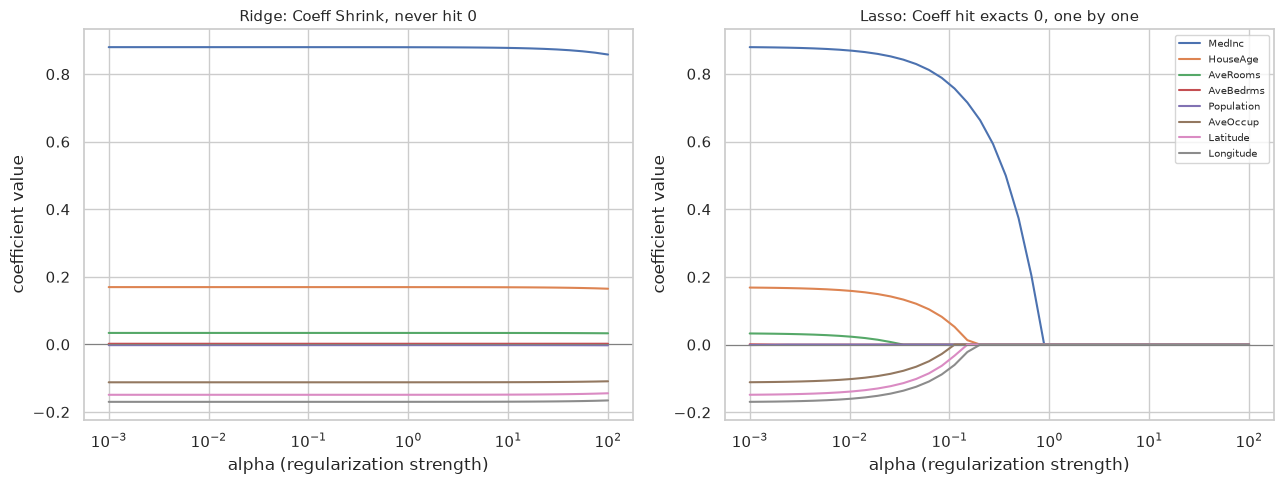

In [21]:
from sklearn.linear_model import Ridge, Lasso

alphas = np.logspace(-3, 2, 40)
ridge_coef_path = np.array([Ridge(alpha=a).fit(X_train_scaled, y_train).coef_ for a in alphas])
lasso_coef_path = np.array([Lasso(alpha=a, max_iter=5000).fit(X_train_scaled, y_train).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, name in enumerate(feature_names):
    axes[0].plot(alphas, ridge_coef_path[:, i], label=name)
    axes[1].plot(alphas, lasso_coef_path[:, i], label=name)

for ax, title in zip(axes, ["Ridge: Coeff Shrink, never hit 0", "Lasso: Coeff hit exacts 0, one by one"]):
    ax.set_xscale("log")
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_xlabel("alpha (regularization strength)")
    ax.set_ylabel("coefficient value")
    ax.set_title(title, fontsize=10.5)

axes[1].legend(fontsize=7.5, loc='upper right')
plt.tight_layout()
plt.show()

In [22]:
# Use RidgeCV and LassoCV
from sklearn.linear_model import RidgeCV, LassoCV

ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_train_scaled, y_train)
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, max_iter=5000).fit(X_train_scaled, y_train)

print(f"Best Ridge Alpha: {ridge_cv.alpha_:.4f}")
print(f"Best Lasso Alpha: {lasso_cv.alpha_:.4f}")

Best Ridge Alpha: 3.5565
Best Lasso Alpha: 0.0026


In [23]:
# Compare their test R²
ridge_test_r2 = r2_score(y_test, ridge_cv.predict(X_test_scaled))
lasso_test_r2 = r2_score(y_test, lasso_cv.predict(X_test_scaled))

print(f"RidgeCV Test R2: {ridge_test_r2:.4f}")
print(f"LassoCV Test R2: {lasso_test_r2:.4f}")

RidgeCV Test R2: 0.8384
LassoCV Test R2: 0.8385


In [27]:
# Compare best hand-picked alpha from Task 3
best_ridge_r2 = r2_score(y_test, ridge.predict(X_test_scaled))
best_lasso_r2 = r2_score(y_test, lasso.predict(X_test_scaled))

print(f"Best hand-picked Ridge R2: {best_ridge_r2}")
print(f"RidgeCV Test R2: {ridge_test_r2}")
print(f"Difference: {abs(best_ridge_r2 - ridge_test_r2)}")

print()

print(f"Best hand-picked Lasso R2: {best_lasso_r2}")
print(f"LassoCV Test R2: {lasso_test_r2}")
print(f"Difference: {abs(best_lasso_r2 - lasso_test_r2)}")

Best hand-picked Ridge R2: 0.8398301033834463
RidgeCV Test R2: 0.8383661543713026
Difference: 0.0014639490121437504

Best hand-picked Lasso R2: -2.5583019858110845e-06
LassoCV Test R2: 0.8384921372221679
Difference: 0.8384946955241537


Cross-validation is more trustworthy because it selects the hyperparameter using only the training data while repeatedly testing on different validation folds, leaving the test set untouched for final evaluation. Tuning by looking at test-set performance can indirectly overfit the test set, making the reported test R² less representative of how the model will perform on unseen data.